# Hyperparameter sensitivity: `tau_max` and `n_years`

Characterizes the two integration/sampling hyperparameters of `sweep_observables`
against the **growth-rate volatility distribution** (the MSB observable
$\sqrt{\pi/2}\,\langle|g-\bar g|\rangle$).

The two knobs are orthogonal:

| knob | role | where |
|---|---|---|
| `tau_max` | horizon of the **rescaled-time** integration. Physical time accrues as $dt/d\tau = 1/M$, so `tau_max` sets the physical span $t_\text{final}$ each run reaches. | `t_span=(0, tau_max)` |
| `n_years` | post-integration **sampling resolution**: the trajectory is mapped to physical time and resampled on `n_years` uniform points before differencing. | `dt_year = t_final / n_years` |

**Integrate-once trick.** A smaller `tau_max` is just a *truncation* of a longer
run, and `n_years` is *pure post-processing*. So we integrate each realization
**once** to the largest `tau_max` on a fine $\tau$-grid (dense at low $\tau$), then
build the whole `(tau_max, n_years)` grid by truncating + resampling — no
re-integration per cell.

**What to expect.**
- `tau_max`: a genuine **convergence** knob. As $\tau$ grows, $t_\text{final}$
  saturates (at criticality $M\!\sim\!\tau$ so $t\!\sim\!\ln\tau$ grows slowly),
  and the volatility distribution should plateau.
- `n_years`: **not** a convergence knob. Volatility is the MAD of *yearly*
  log-growth, so shrinking $dt$ (more years) makes each $\Delta\log S$ smaller.
  It scales as a **power** $\text{vol}\propto dt^{\alpha}$: $\alpha\!\approx\!1$ if
  the flow is smooth ($\Delta\log\!\approx\!\dot{\log}\,dt$), $\alpha\!\approx\!\tfrac12$
  if the critical trajectory is rough/diffusive. The slice below **measures**
  $\alpha$ — `n_years` is a *measurement scale* (set to the empirical cadence),
  not a value to "converge".

In [19]:
import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import glv

In [20]:
# --- global parameters (mirror observables_by_degree.ipynb) ---
N = 1000
C = 50
SIGMA = 0.2

# c-estimator integration
M_CAP = 1e250
RTOL, ATOL, MAX_STEP = 1e-8, 1e-10, 1e3
MU_GRID = np.linspace(0.1, 1.6, 16)

# sensitivity study
n_runs = 16                                    # realizations integrated once each
TAU_MAX_GRID = np.array([1e4, 3e4, 1e5, 3e5, 1e6])   # x-axis
N_YEARS_GRID = np.array([25, 50, 100, 200, 400])     # y-axis
TAU_MAX_MAX = float(TAU_MAX_GRID.max())


def even(d):
    """Round to int, floor at 1, make the sum even (configuration model needs it)."""
    d = np.maximum(1, np.round(np.asarray(d))).astype(int)
    if d.sum() % 2:
        d[0] += 1
    return d

In [21]:
# =====================================================================
# DEGREE DISTRIBUTION  --  comment in EXACTLY ONE block (kept inline)
# =====================================================================

# --- exponential degree:  k ~ Exp(C)  =>  g ~ Exp(1) ---------------
make_degrees = lambda rng: even(rng.exponential(C, N))
nu_pdf = lambda g: np.exp(-g)
LABEL = f"exponential  (mean k = C = {C})"

In [22]:
# --- graph + interaction matrix (inline) ---------------------------
def build_graph(seed):
    rng = np.random.default_rng(seed)
    degs = make_degrees(rng)
    stubs = np.repeat(np.arange(N), degs)
    rng.shuffle(stubs)
    e1, e2 = stubs[0::2], stubs[1::2]
    keep = e1 != e2
    e1, e2 = e1[keep], e2[keep]
    rows = np.concatenate([e1, e2])
    cols = np.concatenate([e2, e1])
    A = sp.csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(N, N))
    A.data[:] = 1.0
    A = A.tolil(); A.setdiag(0); A = A.tocsr(); A.eliminate_zeros()
    coo = A.tocoo()
    z = np.random.default_rng(seed + 999).standard_normal(coo.nnz)
    return coo.row, coo.col, z


def make_W(rows, cols, z, mu):
    return sp.csr_matrix((mu / C + (SIGMA / np.sqrt(C)) * z, (rows, cols)), shape=(N, N))


def shape_c(W):
    def rhs(tau, s):
        y = np.clip(s[:N], 0.0, None); M = s[N]
        ss = y.sum()
        if ss > 0:
            y = y / ss
        F = W @ y; phi = y @ F; sq = y @ y
        dM = 0.0 if M >= M_CAP else 1.0 + M * (phi - sq)
        return np.concatenate([y * (F - phi - y + sq), [dM], [1.0 / M]])

    s0 = np.concatenate([np.full(N, 1.0 / N), [1.0], [0.0]])
    cap = lambda tau, s: s[N] - M_CAP
    cap.terminal = True; cap.direction = 1
    sol = solve_ivp(rhs, (0.0, 1e6), s0, method="LSODA",
                    rtol=RTOL, atol=ATOL, max_step=MAX_STEP, events=cap, t_eval=[1e6])
    final = np.asarray(sol.y_events[0])[-1] if sol.t_events[0].size else sol.y[:, -1]
    y = np.clip(np.asarray(final).ravel()[:N], 0.0, None)
    y = y / y.sum()
    F = W @ y
    return float(y @ F - y @ y)


def locate_mu_c(rows, cols, z, mu_grid):
    cs = np.array([shape_c(make_W(rows, cols, z, mu)) for mu in mu_grid])
    sc = np.where(np.diff(np.sign(cs)))[0]
    if len(sc) == 0:
        raise RuntimeError("c(mu) never changes sign on MU_GRID — widen the grid.")
    i = sc[0]
    mu_c = mu_grid[i] - cs[i] * (mu_grid[i + 1] - mu_grid[i]) / (cs[i + 1] - cs[i])
    return mu_c, cs

In [23]:
# --- pin mu at criticality on a reference realization --------------
rows, cols, z = build_graph(seed=1)
mu_c, _ = locate_mu_c(rows, cols, z, MU_GRID)
print(f"mu_c (c zero-crossing) = {mu_c:.4f}    [{LABEL}]")

mu_c (c zero-crossing) = 0.5919    [exponential  (mean k = C = 50)]


## Integrate each realization once

Fine $\tau$-grid, **dense at low $\tau$** (geomspace) so that even the smallest
`tau_max` truncation keeps plenty of points. One integration per realization, in
parallel, via `glv.sweep_trajectories`.

In [24]:
# tau grid dense at low tau so small-tau_max truncations stay well-resolved
TAU_GRID = np.concatenate([[0.0], np.geomspace(10.0, TAU_MAX_MAX, 3000)])

Ws, initial_states = [], []
for seed in range(n_runs):
    r, c, zz = build_graph(seed)
    Ws.append(make_W(r, c, zz, mu_c))
    x0 = np.random.default_rng(seed + 10_000).uniform(0.1, 1.0, N)
    M0 = x0.sum()
    initial_states.append(np.concatenate([x0 / M0, [M0], [0.0]]))

trajs = glv.sweep_trajectories(
    Ws=Ws, initial_states=initial_states, N=N,
    tau_max=TAU_MAX_MAX, method="RK45", max_step=1e2,
    n_workers=2, t_eval=TAU_GRID, verbose=True,
)
ok = [t for t in trajs if t is not None]
print(f"\nSuccessful runs: {len(ok)}/{n_runs}")

  [1/16] run 1: ok
  [2/16] run 0: ok
  [3/16] run 2: ok
  [4/16] run 3: ok
  [5/16] run 4: ok
  [6/16] run 5: ok
  [7/16] run 6: ok
  [8/16] run 7: ok
  [9/16] run 8: ok
  [10/16] run 9: ok
  [11/16] run 10: ok
  [12/16] run 11: ok
  [13/16] run 12: ok
  [14/16] run 13: ok
  [15/16] run 14: ok
  [16/16] run 15: ok

Successful runs: 16/16


## Build the `(tau_max, n_years)` grid by truncation + resampling

For each cell we reuse the **cross-section** normalization
$S_i = N x_i / \sum_j x_j$ (the MSB convention used by `sweep_observables`),
difference the log on the yearly grid, and pool the per-species volatilities
across all realizations into one distribution per cell.

In [25]:
def cell_volatility(traj, tau_max, n_years):
    """Per-species volatility for one trajectory truncated to tau_max, n_years grid."""
    m = traj["tau"] <= tau_max
    if m.sum() < 3:
        return None
    t = traj["t_phys"][m]
    x = traj["x"][:, m].astype(np.float64)
    t_final = t[-1]
    if not np.isfinite(t_final) or t_final <= t[0]:
        return None

    dt_year = (t_final - t[0]) / n_years
    t_years = np.arange(t[0], t_final, dt_year)
    x_yearly = np.array([np.interp(t_years, t, x[k]) for k in range(x.shape[0])])

    totals = x_yearly.sum(axis=0, keepdims=True)
    totals = np.where(totals > 0, totals, np.nan)
    S = x.shape[0] * x_yearly / totals

    log_S = np.log(np.maximum(S, 1e-15))
    g = np.diff(log_S, axis=1)
    g_bar = g.mean(axis=1, keepdims=True)
    vol = np.sqrt(np.pi / 2.0) * np.mean(np.abs(g - g_bar), axis=1)
    return vol[np.isfinite(vol)], dt_year


nT, nY = len(TAU_MAX_GRID), len(N_YEARS_GRID)
pool = {}                      # (iy, it) -> pooled per-species volatilities
median = np.full((nY, nT), np.nan)
dt_year = np.full((nY, nT), np.nan)

for iy, ny in enumerate(N_YEARS_GRID):
    for it, tm in enumerate(TAU_MAX_GRID):
        vols, dts = [], []
        for traj in ok:
            res = cell_volatility(traj, tm, int(ny))
            if res is not None:
                vols.append(res[0]); dts.append(res[1])
        if vols:
            v = np.concatenate(vols)
            pool[(iy, it)] = v
            median[iy, it] = np.median(v)
            dt_year[iy, it] = np.mean(dts)

print("median volatility grid (rows=n_years, cols=tau_max):")
print(np.round(median, 4))

median volatility grid (rows=n_years, cols=tau_max):
[[0.0212 0.0367 0.0505 0.0589 0.0643]
 [0.0108 0.0184 0.0252 0.0294 0.032 ]
 [0.0054 0.0092 0.0126 0.0147 0.016 ]
 [0.0027 0.0046 0.0063 0.0073 0.008 ]
 [0.0014 0.0023 0.0031 0.0037 0.004 ]]


## Physical horizon and sampling interval

Before the heatmaps, the two quantities the knobs actually set. `tau_max` fixes the
physical horizon $t_\text{final}$ (only $t_\text{final}$ depends on `tau_max`, not
`n_years`); together they set the **physical sampling interval**
$dt_\text{year}=t_\text{final}/n_\text{years}$ — the real measurement scale.

In [26]:
# t_final depends only on tau_max; report it (mean over realizations)
t_final = np.array([
    np.mean([t["t_phys"][t["tau"] <= tm][-1] for t in ok])
    for tm in TAU_MAX_GRID
])
print("t_final vs tau_max:", dict(zip([f"{t:.0e}" for t in TAU_MAX_GRID],
                                      np.round(t_final, 2))))
print("\ndt_year grid (rows=n_years, cols=tau_max):")
print(np.round(dt_year, 4))

t_final vs tau_max: {'1e+04': np.float64(3.61), '3e+04': np.float64(5.43), '1e+05': np.float64(10.05), '3e+05': np.float64(22.55), '1e+06': np.float64(66.16)}

dt_year grid (rows=n_years, cols=tau_max):
[[0.1443 0.2171 0.4019 0.902  2.6465]
 [0.0721 0.1085 0.2009 0.451  1.3233]
 [0.0361 0.0543 0.1005 0.2255 0.6616]
 [0.018  0.0271 0.0502 0.1128 0.3308]
 [0.009  0.0136 0.0251 0.0564 0.1654]]


## Heatmaps

**A — median volatility** (raw magnitude). At fixed `tau_max`, vol $\propto
1/n_\text{years}$ (scale only); across `tau_max` it also rises because larger
`tau_max` $\Rightarrow$ larger $t_\text{final}\Rightarrow$ larger $dt_\text{year}$.
So **A is essentially a map of $dt_\text{year}$** — a measurement-scale effect, not
a numerical artefact.

**B — shape convergence.** Each cell's volatilities are normalized by their own
median, killing the $dt_\text{year}$ scale, then compared (KS) to the converged
cell (max `tau_max`, max `n_years`). What remains is **distribution shape**. The
expectation: ~flat down the `n_years` axis (shape is scale-free in `n_years`) and
**decreasing along `tau_max`** as transient contamination washes out — this is the
real convergence signal, and it tells you the smallest safe `tau_max`.

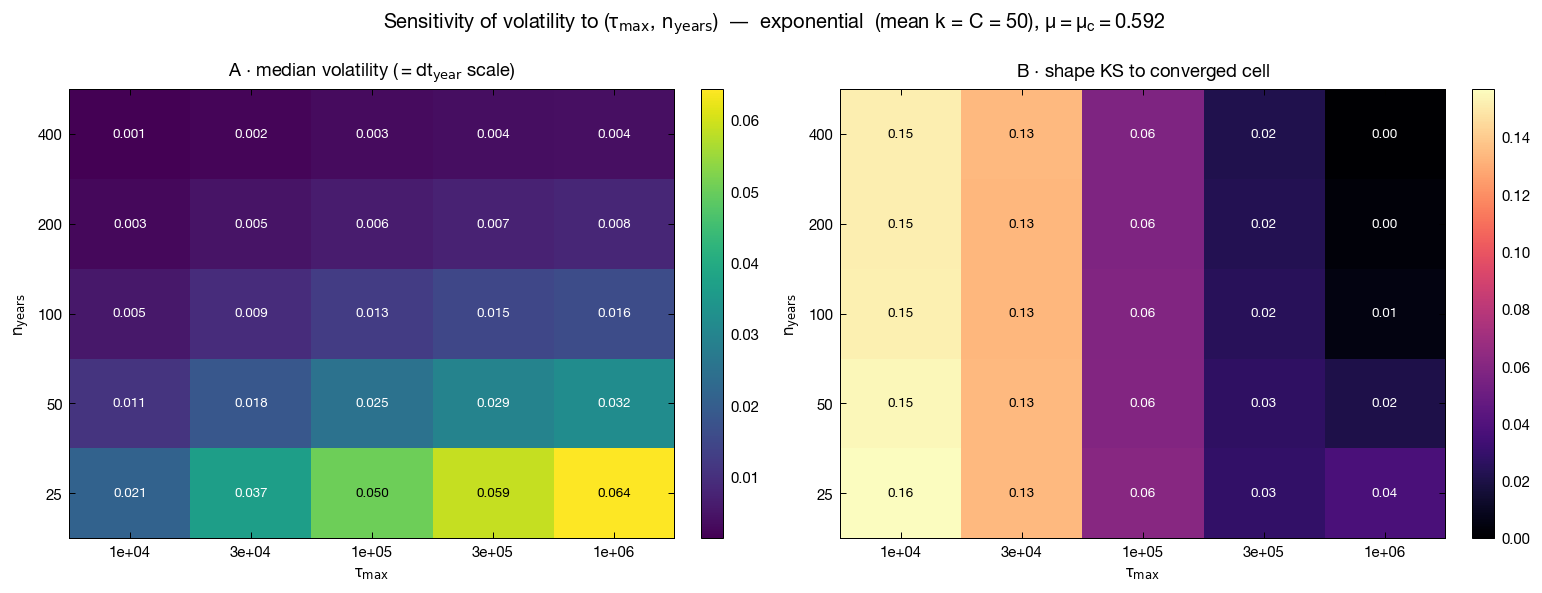

In [29]:
# B: shape KS — normalize each cell by its own median, compare to converged cell
ref_shape = pool[(nY - 1, nT - 1)]
ref_shape = ref_shape / np.median(ref_shape)
shape_ks = np.full((nY, nT), np.nan)
for iy in range(nY):
    for it in range(nT):
        v = pool.get((iy, it))
        if v is not None:
            shape_ks[iy, it] = ks_2samp(v / np.median(v), ref_shape).statistic

glv.apply_style()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

def heat(ax, Z, title, cmap, fmt):
    im = ax.imshow(Z, origin="lower", aspect="auto", cmap=cmap)
    ax.set_xticks(range(nT)); ax.set_xticklabels([f"{t:.0e}" for t in TAU_MAX_GRID])
    ax.set_yticks(range(nY)); ax.set_yticklabels([str(int(y)) for y in N_YEARS_GRID])
    ax.set_xlabel(r"$\tau_{\max}$"); ax.set_ylabel(r"$n_\mathrm{years}$"); ax.set_title(title)
    norm = im.norm; sm = im.cmap
    for iy in range(nY):
        for it in range(nT):
            if np.isfinite(Z[iy, it]):
                r, g, b, _ = sm(norm(Z[iy, it]))      # mapped cell color
                lum = 0.299 * r + 0.587 * g + 0.114 * b
                ax.text(it, iy, format(Z[iy, it], fmt), ha="center", va="center",
                        fontsize=8, color="k" if lum > 0.55 else "w")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

heat(axes[0], median, r"A $\cdot$ median volatility ($=dt_\mathrm{year}$ scale)", "viridis", ".3f")
heat(axes[1], shape_ks, r"B $\cdot$ shape KS to converged cell", "magma", ".2f")
fig.suptitle(rf"Sensitivity of volatility to $(\tau_{{\max}},\, n_\mathrm{{years}})$"
             rf"  —  {LABEL}, $\mu=\mu_c={mu_c:.3f}$")
fig.tight_layout()
plt.show()

## 1-D slices: separating the two roles

- **`tau_max` (left) — convergence.** Shape KS vs `tau_max`, one line per
  `n_years` (they overlap: shape doesn't care about `n_years`). The smallest
  `tau_max` past which KS drops below a tolerance (dashed) is the safe default.
- **`n_years` (right) — pure scale.** Median volatility vs `n_years` at fixed
  `tau_max`, log–log, with the fitted power $\text{vol}\propto
  n_\text{years}^{-\alpha}$. $\alpha\!\approx\!1$ ⇒ smooth flow (each $\Delta\log$
  is a derivative $\times\,dt$); $\alpha\!\approx\!\tfrac12$ ⇒ diffusive. A clean
  power law confirms `n_years` only sets the measurement scale.

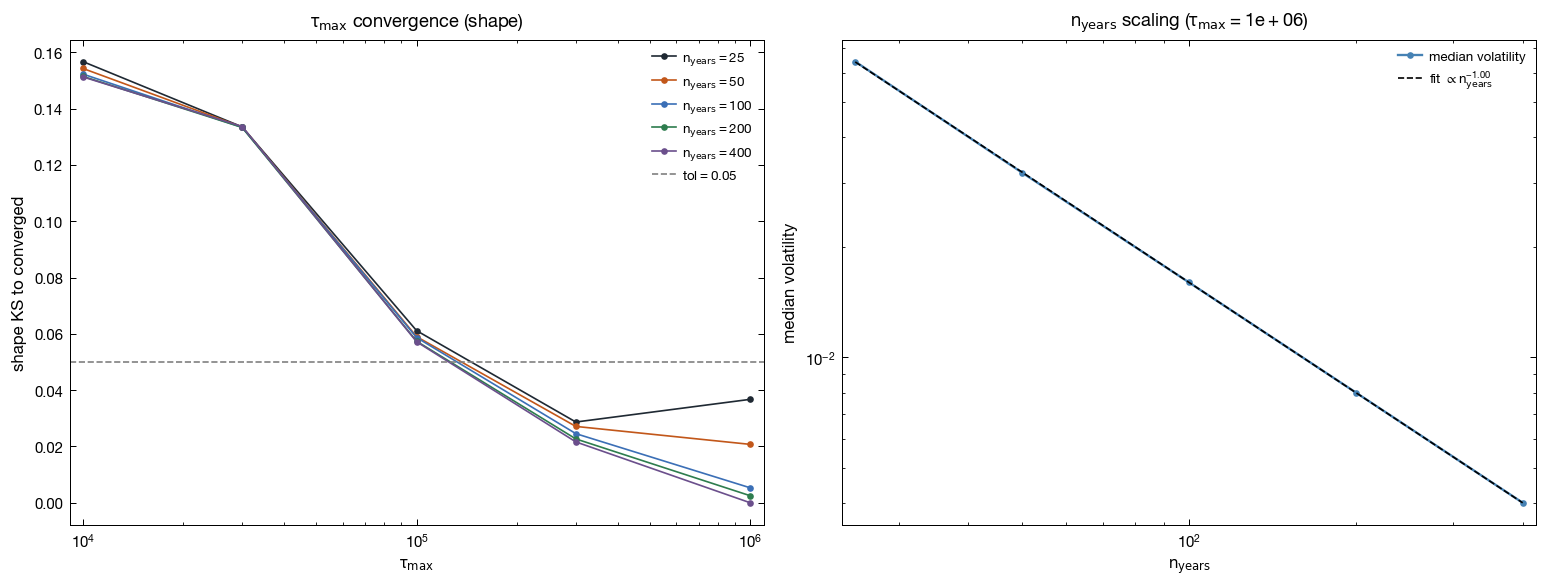

n_years scaling exponent alpha = -1.000  ->  smooth flow
smallest converged tau_max (shape KS < 0.05) per n_years: {25: np.float64(300000.0), 50: np.float64(300000.0), 100: np.float64(300000.0), 200: np.float64(300000.0), 400: np.float64(300000.0)}


In [28]:
TOL = 0.05
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

for iy, ny in enumerate(N_YEARS_GRID):
    axL.plot(TAU_MAX_GRID, shape_ks[iy], "o-", lw=1, label=rf"$n_\mathrm{{years}}={int(ny)}$")
axL.axhline(TOL, color="0.5", ls="--", lw=1, label=rf"tol$={TOL}$")
axL.set_xscale("log")
axL.set(xlabel=r"$\tau_{\max}$", ylabel="shape KS to converged",
        title=r"$\tau_{\max}$ convergence (shape)")
axL.legend(fontsize=8)

it = nT - 1                                   # largest tau_max
m = median[:, it]
good = np.isfinite(m)
axR.plot(N_YEARS_GRID, m, "o-", color="steelblue", label="median volatility")
alpha, logc = np.polyfit(np.log(N_YEARS_GRID[good]), np.log(m[good]), 1)
fit = np.exp(logc) * N_YEARS_GRID.astype(float) ** alpha
axR.plot(N_YEARS_GRID, fit, "k--", lw=1,
         label=rf"fit $\propto n_\mathrm{{years}}^{{{alpha:.2f}}}$")
axR.set_xscale("log"); axR.set_yscale("log")
axR.set(xlabel=r"$n_\mathrm{years}$", ylabel="median volatility",
        title=rf"$n_\mathrm{{years}}$ scaling ($\tau_{{\max}}={TAU_MAX_GRID[it]:.0e}$)")
axR.legend(fontsize=8)
fig.tight_layout()
plt.show()

# converged tau_max per n_years row (first cell with KS < TOL)
conv = []
for iy, ny in enumerate(N_YEARS_GRID):
    below = np.where(shape_ks[iy] < TOL)[0]
    conv.append(TAU_MAX_GRID[below[0]] if below.size else np.nan)
regime = "smooth flow" if alpha < -0.75 else ("diffusive" if alpha > -0.6 else "intermediate")
print(f"n_years scaling exponent alpha = {alpha:.3f}  ->  {regime}")
print(f"smallest converged tau_max (shape KS < {TOL}) per n_years:",
      dict(zip([int(y) for y in N_YEARS_GRID], conv)))

## Takeaways

- **`n_years` is a measurement-scale knob, not a convergence knob.** At fixed
  `tau_max` the volatility magnitude scales as a clean power
  $\text{vol}\propto n_\text{years}^{-\alpha}$ and the distribution *shape* is
  unchanged. Set `n_years` to match the empirical sampling cadence (or, equivalently,
  fix the physical interval $dt_\text{year}=t_\text{final}/n_\text{years}$) — there
  is no value to "converge" to.
- **`tau_max` is the real convergence knob.** It sets the physical horizon
  $t_\text{final}$; too small and the *transient* dominates, distorting the
  volatility-distribution shape. Increase `tau_max` until the shape KS plateaus
  (heatmap B / left slice), then stop.
- **Don't tune the two for magnitude independently** — magnitude is governed by
  $dt_\text{year}$, which both knobs feed. Fix `tau_max` from the shape-convergence
  threshold above, fix `n_years`/`dt_year` from the data cadence.